In [25]:
import torch
import lightning as L
from sklearn.datasets import make_moons
from dal_toolbox.active_learning import ActiveLearningDataModule
from dal_toolbox.models.deterministic import DeterministicModel
from dal_toolbox.active_learning.strategies import LeastConfidentSampling
from dal_toolbox.models.deterministic.simplenet import SimpleNet as Net

In [26]:
from dal_toolbox.utils import seed_everything
seed_everything(1)

Seed set to 1


In [27]:
# Create the twoo moons dataset
X, y = make_moons(200, noise=.1, random_state=42)

# Transform into a TensorDataset
X, y = torch.tensor(X).float(), torch.tensor(y).long()
tensor_dataset = torch.utils.data.TensorDataset(X, y)

# Setup the AL-Datamodule provided by the dal_toolbox and initialize with four randomly labeled samples
al_datamodule = ActiveLearningDataModule(tensor_dataset, train_batch_size=32)
al_datamodule.random_init(n_samples=4, class_balanced=True)

# Initialize a model and wrap it with the DeterministicModel Wrapper provided by the DAL-Toolbox
model = Net(dropout_rate=0., num_classes=2)
model = DeterministicModel(model, optimizer=torch.optim.SGD(model.parameters(), lr=1e-1, momentum=.9))

# Initialize an AL-Strategy
al_strategy = LeastConfidentSampling()

# Perfom AL-Cycles
for i_cycle in range(6):
    # Acquire new Labels
    if i_cycle != 0:
        indices = al_strategy.query(model=model, al_datamodule=al_datamodule, acq_size=1)
        al_datamodule.update_annotations(indices)

    # Refit the model on the labeled data
    model.reset_states()
    trainer = L.Trainer(max_epochs=50, enable_progress_bar=False)
    trainer.fit(model, al_datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleNet        | 17.2 K
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleNet        | 17.2 K
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
----

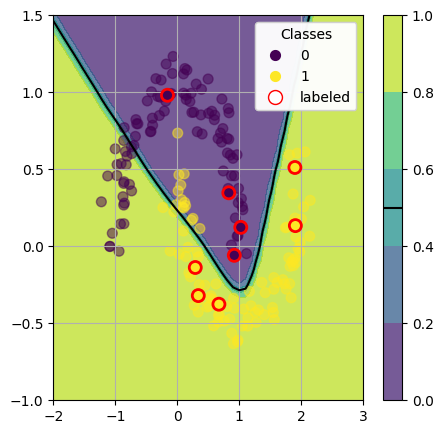

In [28]:
import pylab as plt
from matplotlib.lines import Line2D
import numpy as np

def dataset_to_xy(dataset):
    X, y = [], []
    for batch in dataset:
        X.append(batch[0])
        y.append(batch[1])
    X = torch.stack(X).float()
    y = torch.Tensor(y).long()
    return X, y


@torch.no_grad()
def plot_contour(model, X_l, y_l, X_u=None, y_u=None, ax=None, x_domain=(-3, 3), y_domain=(-3, 3), forward_mode='single'):
    model.eval()
    model.cpu()
    origin = 'lower'
    xx, yy = torch.meshgrid(torch.linspace(x_domain[0], x_domain[1], 51), torch.linspace(y_domain[0], y_domain[1], 51), indexing='ij')
    zz = torch.stack((xx.flatten(), yy.flatten()), dim=1)

    if forward_mode == 'single':
        logits = model(zz)
        probas = logits.softmax(-1)
    elif forward_mode == 'mc':
        logits = model.mc_forward(zz)
        probas = logits.softmax(-1)
        probas = probas.mean(1)
    elif forward_mode == 'mean_field':
        logits = model(zz, mean_field=True)
        probas = logits.softmax(-1)
    else:
        raise NotImplementedError('This forward method is not taken account for. Choose one in [single, mc, mean_field]!')
        

    zz = probas[:, 1].view(xx.shape)

    if X_u != None:
        scatter = plt.scatter(X_l[:, 0], X_l[:, 1], c=y_l, s=75, edgecolors='red', linewidths=2, zorder=5)
        plt.scatter(X_u[:, 0], X_u[:, 1], c=y_u, s=50, alpha=0.5, label='unlabeled')
    else:
        scatter = plt.scatter(X_l[:, 0], X_l[:, 1], c=y_l, s=50, zorder=5, edgecolors='black')

    # Automatically generate a legend
    leg_el = scatter.legend_elements()
    # Add the "labeled" class if there are unlabeled samples present
    if X_u != None:
        leg_el[0].append(Line2D([0], [0], marker='o', color='red', markerfacecolor='white', markeredgecolor='red', markersize=10, linestyle='None'))
        leg_el[1].append("labeled")
    legend1 = plt.legend(*leg_el,
                    loc="upper right", title="Classes")
    plt.gca().add_artist(legend1)

    CS = plt.contourf(xx.numpy(), yy.numpy(), zz.numpy(), alpha=.75, zorder=-1, levels=np.linspace(0, 1, 6), origin=origin)
    CS2 = plt.contour(CS, levels=[0.5], colors='black', origin=origin)
    cbar = plt.colorbar(CS)
    cbar.add_lines(CS2)

    plt.grid(visible=True)

plt.figure(figsize=(5, 5))
X, y = dataset_to_xy(al_datamodule.query_dataset)
X_l, y_l = X[al_datamodule.labeled_indices], y[al_datamodule.labeled_indices]
X_u, y_u = X[al_datamodule.unlabeled_indices], y[al_datamodule.unlabeled_indices]
plot_contour(model, X_l=X_l, y_l=y_l, X_u=X_u, y_u=y_u, x_domain=(-2,3), y_domain=(-1, 1.5))
#plt.show()
plt.savefig('readme_example_decision_bounday_1.png')

In [29]:
spectral_norm_params = dict(
    norm_bound=.9,
    n_power_iterations=1
)
gp_params = dict(
    num_inducing=1024,
    kernel_scale=0.05,
    random_feature_type='orf',
    scale_random_features=False
)

In [30]:
from dal_toolbox.models.sngp import SNGPModel
from dal_toolbox.models.deterministic.simplenet import SimpleSNGP as SNGPNet

# Create the twoo moons dataset
X, y = make_moons(200, noise=.1, random_state=42)

# Transform into a TensorDataset
X, y = torch.tensor(X).float(), torch.tensor(y).long()
tensor_dataset = torch.utils.data.TensorDataset(X, y)

# Setup the AL-Datamodule provided by the dal_toolbox and initialize with four randomly labeled samples
al_datamodule = ActiveLearningDataModule(tensor_dataset, train_batch_size=32)
al_datamodule.random_init(n_samples=4, class_balanced=True)

# Initialize a model and wrap it with the DeterministicModel Wrapper provided by the DAL-Toolbox
model = SNGPNet(num_classes=2, use_spectral_norm=True, spectral_norm_params=spectral_norm_params, gp_params=gp_params)
model = SNGPModel(model, optimizer=torch.optim.SGD(model.parameters(),  lr=1e-2, weight_decay=1e-2, momentum=.9))

# Initialize an AL-Strategy
al_strategy = LeastConfidentSampling()

# Perfom AL-Cycles
for i_cycle in range(6):
    # Acquire new Labels
    if i_cycle != 0:
        indices = al_strategy.query(model=model, al_datamodule=al_datamodule, acq_size=1)
        al_datamodule.update_annotations(indices)

    # Refit the model on the labeled data
    model.reset_states()
    trainer = L.Trainer(max_epochs=50, enable_progress_bar=False)
    trainer.fit(model, al_datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleSNGP       | 101 K 
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
101 K     Trainable params
0         Non-trainable params
101 K     Total params
0.406     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleSNGP       | 101 K 
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metric

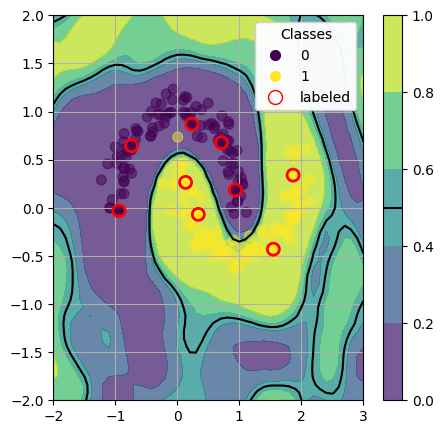

In [31]:
plt.figure(figsize=(5, 5))
X, y = dataset_to_xy(al_datamodule.query_dataset)
X_l, y_l = X[al_datamodule.labeled_indices], y[al_datamodule.labeled_indices]
X_u, y_u = X[al_datamodule.unlabeled_indices], y[al_datamodule.unlabeled_indices]
plot_contour(model, X_l=X_l, y_l=y_l, X_u=X_u, y_u=y_u, x_domain=(-2,3), y_domain=(-2, 2))
#plt.show()
plt.savefig('readme_example_decision_bounday_2.png')